## **Data Loading**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATA_PATH = '/content/drive/MyDrive/DV-TM/DATA'
print('Files found:', os.listdir(DATA_PATH))

Mounted at /content/drive
Files found: ['test.jsonl', 'train.jsonl']


## **Exploratory Data Analysis**

In [2]:
import json

def load_jsonl(path):
    """Load a JSONL file into a list of dicts."""
    with open(path, 'r') as f:
        return [json.loads(line) for line in f]

train_data = load_jsonl(os.path.join(DATA_PATH, 'train.jsonl'))
test_data  = load_jsonl(os.path.join(DATA_PATH, 'test.jsonl'))

print(f'Train samples: {len(train_data)}')
print(f'Test samples:  {len(test_data)}')
print(f'\nTrain keys: {list(train_data[0].keys())}')
print(f'Test keys:  {list(test_data[0].keys())}')
print(f'\n--- Sample Train entry ---')
print(json.dumps(train_data[0], indent=2))

Train samples: 3200
Test samples:  800

Train keys: ['id', 'tokens', 'labels']
Test keys:  ['id', 'tokens']

--- Sample Train entry ---
{
  "id": "job_00000",
  "tokens": [
    "NextGen",
    "Industries",
    "is",
    "hiring",
    "a",
    "DevOps",
    "Engineer",
    "in",
    "San",
    "Francisco",
    "with",
    "SQL",
    "experience."
  ],
  "labels": [
    "B-COMPANY",
    "I-COMPANY",
    "O",
    "O",
    "O",
    "B-JOBTITLE",
    "I-JOBTITLE",
    "O",
    "B-LOCATION",
    "I-LOCATION",
    "O",
    "B-SKILL",
    "O"
  ]
}


**BIO tagging scheme**:

* **B-**: Beginning - marks the first token of an entity.
* **I-**: Inside - marks every subsequent token of the same entity.
* **O**: Outside - means the token is not part of any entity.

Before doing any analysis or visualization, we want to validate data integrity. The following sanity checks cover:

* Token-Label alignment, to check if the every sample's tokens and labels have the same length.
* Duplicate IDs: to check that every sample has a unique identifier.
* ID overlap between train and test: to assess that the two splits are truly separated.
* BIO sequence validity: to understand if every I- tags always have a proper B- before them.
* Duplicate Train texts: to check whether the training set contains repeated samples that could bias the model toward certain patterns.
* Text overlap Train/Test: to make sure that in evaluation phase, we can trust our model's test performance.
* Out-Of-Vocabulary (OOV): to check if our model will encounter words at the test time that it has never seen during the training phase.

In [3]:
import numpy as np
from collections import Counter

# 1. Token-label alignment
mismatches = [r['id'] for r in train_data if len(r['tokens']) != len(r['labels'])]
print(f'Token-label mismatches: {len(mismatches)}')

# 2. Duplicate IDs
train_ids = [r['id'] for r in train_data]
test_ids  = [r['id'] for r in test_data]
print(f'Duplicate train IDs:   {len(train_ids) - len(set(train_ids))}')
print(f'Duplicate test IDs:    {len(test_ids) - len(set(test_ids))}')
print(f'Train/test ID overlap: {len(set(train_ids) & set(test_ids))}')

# 3. Duplicate texts
train_texts = [' '.join(r['tokens']) for r in train_data]
test_texts  = [' '.join(r['tokens']) for r in test_data]
print(f'Duplicate train texts: {len(train_texts) - len(set(train_texts))}')
print(f'Text overlap train/test: {len(set(train_texts) & set(test_texts))}')

# 4. BIO sequence validity
bio_errors = 0
for r in train_data:
    for i, lab in enumerate(r['labels']):
        if lab.startswith('I-'):
            etype = lab[2:]
            if i == 0 or (r['labels'][i-1] != f'B-{etype}' and r['labels'][i-1] != f'I-{etype}'):
                bio_errors += 1
print(f'BIO sequence errors:   {bio_errors}')

# 5. Label set
all_labels = set(l for r in train_data for l in r['labels'])
print(f'\nLabel set ({len(all_labels)}): {sorted(all_labels)}')

# 6. Vocabulary overlap
train_vocab = set(t for r in train_data for t in r['tokens'])
test_vocab  = set(t for r in test_data  for t in r['tokens'])
oov = test_vocab - train_vocab
print(f'\nTrain vocab: {len(train_vocab)} | Test vocab: {len(test_vocab)} | OOV in test: {len(oov)}')

Token-label mismatches: 0
Duplicate train IDs:   0
Duplicate test IDs:    0
Train/test ID overlap: 0
Duplicate train texts: 58
Text overlap train/test: 28
BIO sequence errors:   0

Label set (9): ['B-COMPANY', 'B-JOBTITLE', 'B-LOCATION', 'B-SKILL', 'I-COMPANY', 'I-JOBTITLE', 'I-LOCATION', 'I-SKILL', 'O']

Train vocab: 136 | Test vocab: 136 | OOV in test: 0


All checks passed. The data is structurally clean with zero mismatches, zero BIO errors, and zero OOV tokens. The 28 text overlaps with test are not harmful since the test set contains no labels.

However, the 58 duplicate sentences in the training set could bias the model toward certain patterns during training. To ensure a clean and unbiased dataset, we remove these duplicates, keeping only the first occurrence of each unique sentence.

In [4]:
# Remove duplicate texts from training set (keep first occurrence)
seen_texts = set()
train_data_unique = []
duplicates_removed = 0

for sample in train_data:
    text = ' '.join(sample['tokens'])
    if text not in seen_texts:
        seen_texts.add(text)
        train_data_unique.append(sample)
    else:
        duplicates_removed += 1

print(f'Original train samples: {len(train_data)}')
print(f'Duplicates removed: {duplicates_removed}')
print(f'Clean train samples: {len(train_data_unique)}')

# Replace train_data with deduplicated version
train_data = train_data_unique

Original train samples: 3200
Duplicates removed: 58
Clean train samples: 3142


### **Sequence Length Distribution**

In [5]:
train_lens = [len(r['tokens']) for r in train_data]
test_lens  = [len(r['tokens']) for r in test_data]

print('TRAIN:')
print(f'  Min: {min(train_lens)}, Max: {max(train_lens)}, Mean: {np.mean(train_lens):.1f}, Std: {np.std(train_lens):.1f}')
print(f'\nTEST:')
print(f'  Min: {min(test_lens)}, Max: {max(test_lens)}, Mean: {np.mean(test_lens):.1f}, Std: {np.std(test_lens):.1f}')

TRAIN:
  Min: 9, Max: 16, Mean: 12.7, Std: 1.5

TEST:
  Min: 9, Max: 16, Mean: 12.7, Std: 1.5


Both train and test have identical statistics, same range (9 to 16), same mean (12.7), same standard deviation (1.5). This confirms that both splits come from the exact same generative process.

Since train and test set are perfectly comparable, we won't have to worry about distribution shift.

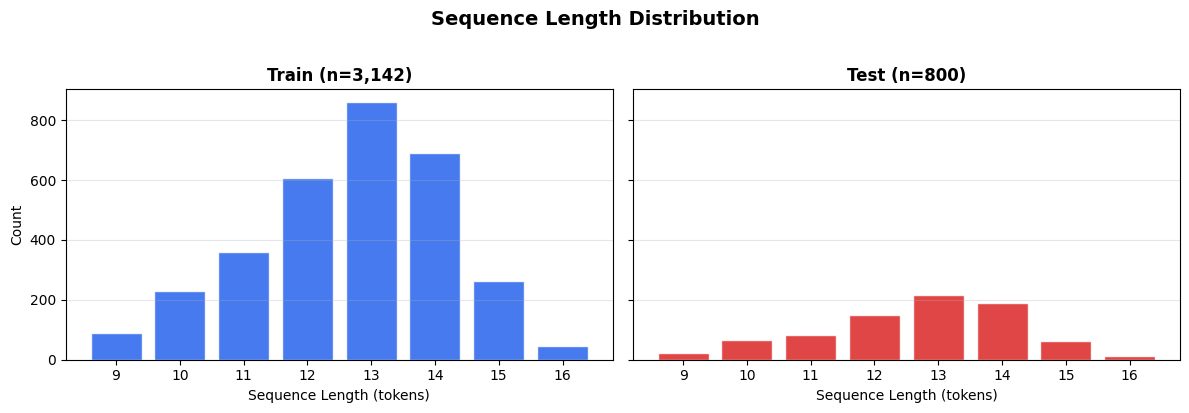

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, lens, title, color in [
    (axes[0], train_lens, f'Train (n={len(train_data):,})', '#2563eb'),
    (axes[1], test_lens,  f'Test (n={len(test_data):,})',  '#dc2626')
]:
    dist = Counter(lens)
    x = sorted(dist.keys())
    y = [dist[k] for k in x]
    ax.bar(x, y, color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Sequence Length (tokens)')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Count')
plt.suptitle('Sequence Length Distribution', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The chart confirms what the numbers told us. Both distributions have the same bell-shaped pattern centered around 13 tokens, with the test set being simply a scaled down version of the train set. The shapes are virtually identical, which means there's no distribution shift between the splits.

The next step is to analyze the label distribution, that is how the 9 BIO tags are distributed across all tokens. This will tell us about class imbalance, which is critical for choosing loss functions and evaluation metrics later.

### **Label Distribution**

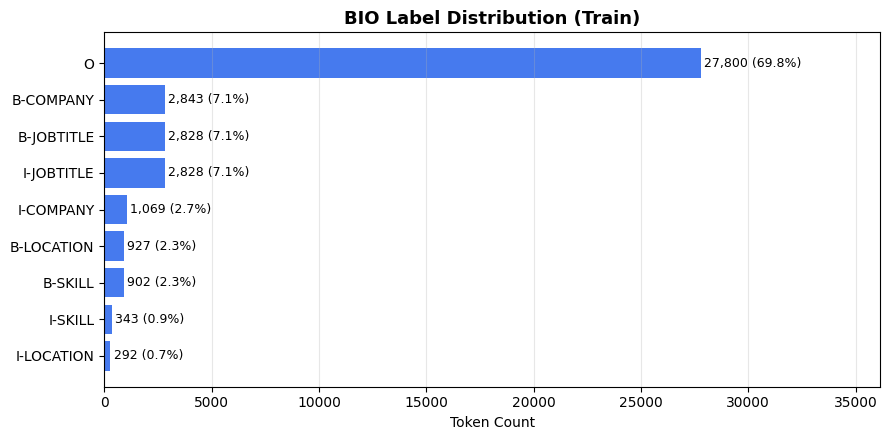

In [7]:
all_label_list = [l for r in train_data for l in r['labels']]
label_counts = Counter(all_label_list)
total = len(all_label_list)

labels_sorted = sorted(label_counts.items(), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(9, 4.5))
names = [l[0] for l in labels_sorted][::-1]
vals  = [l[1] for l in labels_sorted][::-1]
ax.barh(names, vals, color='#2563eb', alpha=0.85)
for i, v in enumerate(vals):
    ax.text(v + 150, i, f'{v:,} ({100*v/total:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Token Count')
ax.set_title('BIO Label Distribution (Train)', fontweight='bold', fontsize=13)
ax.set_xlim(0, max(vals)*1.3)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### **Entity Value Distribution**

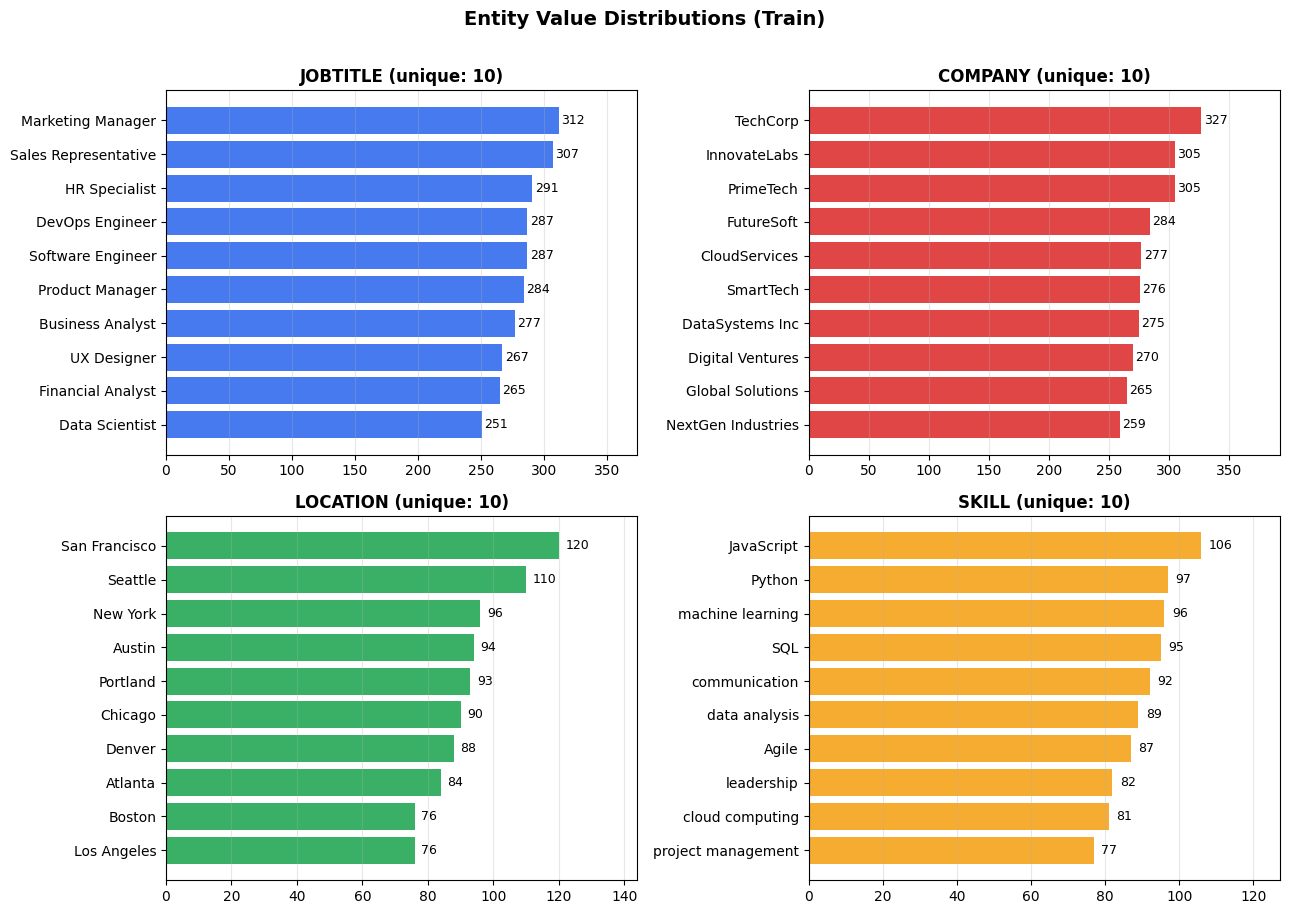

In [8]:
def extract_entities(tokens, labels):
    """Extract entities as (type, text) tuples from BIO-tagged sequences."""
    entities = []
    current_type, current_tokens = None, []
    for tok, lab in zip(tokens, labels):
        if lab.startswith('B-'):
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type = lab[2:]
            current_tokens = [tok]
        elif lab.startswith('I-') and current_type == lab[2:]:
            current_tokens.append(tok)
        else:
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type, current_tokens = None, []
    if current_type:
        entities.append((current_type, ' '.join(current_tokens)))
    return entities

# Collect all entities
all_entities = []
for r in train_data:
    all_entities.extend(extract_entities(r['tokens'], r['labels']))

# Group by type
type_entities = {}
for etype, text in all_entities:
    type_entities.setdefault(etype, []).append(text)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette = {'JOBTITLE': '#2563eb', 'COMPANY': '#dc2626',
           'LOCATION': '#16a34a', 'SKILL': '#f59e0b'}

for ax, etype in zip(axes.flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']):
    vals = Counter(type_entities[etype]).most_common(10)
    names  = [v[0] for v in vals][::-1]
    counts = [v[1] for v in vals][::-1]
    ax.barh(names, counts, color=palette[etype], alpha=0.85)
    for i, v in enumerate(counts):
        ax.text(v + 2, i, str(v), va='center', fontsize=9)
    ax.set_title(f'{etype} (unique: {len(set(type_entities[etype]))})',
                 fontweight='bold')
    ax.set_xlim(0, max(counts) * 1.2)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Entity Value Distributions (Train)', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

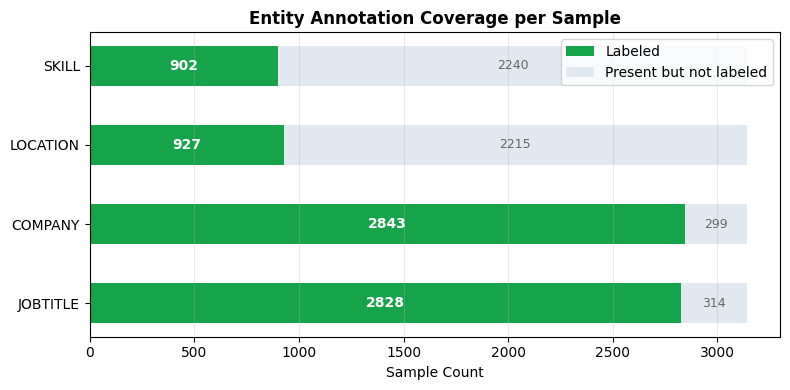

In [9]:
entity_types = ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']

coverage = {}
for etype in entity_types:
    has = sum(1 for r in train_data if any(l.startswith(f'B-{etype}') for l in r['labels']))
    coverage[etype] = has

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(entity_types))
labeled   = [coverage[e] for e in entity_types]
unlabeled = [len(train_data) - coverage[e] for e in entity_types]

ax.barh(x, labeled, height=0.5, color='#16a34a', label='Labeled')
ax.barh(x, unlabeled, height=0.5, left=labeled, color='#e2e8f0', label='Present but not labeled')
ax.set_yticks(x)
ax.set_yticklabels(entity_types)
ax.set_xlabel('Sample Count')
ax.set_title('Entity Annotation Coverage per Sample', fontweight='bold')
ax.legend()
for i, (l, u) in enumerate(zip(labeled, unlabeled)):
    ax.text(l/2, i, f'{l}', va='center', ha='center', fontweight='bold', color='white')
    ax.text(l + u/2, i, f'{u}', va='center', ha='center', fontsize=9, color='#666')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import random
random.seed(34)

shuffled_data = train_data.copy()
random.shuffle(shuffled_data)

print("SAME WORD, DIFFERENT LABELS (randomized):")
print("=" * 60)

# SKILL
print("\n--- SKILL ---")
skill_words = ['Python', 'SQL', 'JavaScript']
for word in skill_words:
    print(f'\n"{word}":')
    count = 0
    for r in shuffled_data:
        for i, (tok, lab) in enumerate(zip(r['tokens'], r['labels'])):
            if tok.rstrip('.,;:') == word:
                context = ' '.join(r['tokens'][max(0,i-2):i+3])
                if count < 3:
                    print(f'  Label: {lab:10s} | Context: "...{context}..."')
                    count += 1
    print(f'  ...')

# LOCATION
print("\n\n--- LOCATION ---")
location_words = ['Boston', 'Denver', 'Atlanta']
for word in location_words:
    print(f'\n"{word}":')
    count = 0
    for r in shuffled_data:
        for i, (tok, lab) in enumerate(zip(r['tokens'], r['labels'])):
            if tok.rstrip('.,;:') == word:
                context = ' '.join(r['tokens'][max(0,i-2):i+3])
                if count < 3:
                    print(f'  Label: {lab:10s} | Context: "...{context}..."')
                    count += 1
    print(f'  ...')

# COMPANY
print("\n\n--- COMPANY ---")
company_words = ['SmartTech', 'InnovateLabs', 'TechCorp']
for word in company_words:
    print(f'\n"{word}":')
    count = 0
    for r in shuffled_data:
        for i, (tok, lab) in enumerate(zip(r['tokens'], r['labels'])):
            if tok.rstrip('.,;:') == word:
                context = ' '.join(r['tokens'][max(0,i-2):i+3])
                if count < 3:
                    print(f'  Label: {lab:10s} | Context: "...{context}..."')
                    count += 1
    print(f'  ...')

# JOBTITLE
print("\n\n--- JOBTITLE ---")
jobtitle_words = ['Software', 'Data', 'Marketing']
for word in jobtitle_words:
    print(f'\n"{word}":')
    count = 0
    for r in shuffled_data:
        for i, (tok, lab) in enumerate(zip(r['tokens'], r['labels'])):
            if tok.rstrip('.,;:') == word:
                context = ' '.join(r['tokens'][max(0,i-2):i+3])
                if count < 3:
                    print(f'  Label: {lab:10s} | Context: "...{context}..."')
                    count += 1
    print(f'  ...')

SAME WORD, DIFFERENT LABELS (randomized):

--- SKILL ---

"Python":
  Label: O          | Context: "...Required : Python...."
  Label: O          | Context: "...Skills : Python...."
  Label: O          | Context: "...skill : Python...."
  ...

"SQL":
  Label: O          | Context: "...Required : SQL...."
  Label: O          | Context: "...skill : SQL...."
  Label: O          | Context: "...Required : SQL...."
  ...

"JavaScript":
  Label: O          | Context: "...proficient in JavaScript...."
  Label: O          | Context: "...Requirements : JavaScript. Location :..."
  Label: O          | Context: "...proficient in JavaScript...."
  ...


--- LOCATION ---

"Boston":
  Label: O          | Context: "...Ventures , Boston. Key skill..."
  Label: O          | Context: "...SmartTech , Boston. Key skill..."
  Label: O          | Context: "...Location : Boston...."
  ...

"Denver":
  Label: B-LOCATION | Context: "...Engineer in Denver with communication..."
  Label: O          | Context: "..

Questo ci mostrerà quanti sample hanno solo COMPANY+JOBTITLE, quanti hanno tutte e 4 le entità, quanti ne hanno solo una, ecc. È la mappa che ci servirà per capire esattamente dove intervenire nel data cleaning. Fammi vedere i risultati.

In [11]:
def get_labeled_types(labels):
    return tuple(sorted(set(l.split('-')[1] for l in labels if l != 'O')))

combo_counts = Counter(get_labeled_types(r['labels']) for r in train_data)

print("Entity type combinations per sample:")
print("=" * 50)
for combo, c in combo_counts.most_common():
    print(f'  {" + ".join(combo):45s} → {c:4d} samples ({100*c/len(train_data):.1f}%)')

Entity type combinations per sample:
  COMPANY + JOBTITLE                            → 1310 samples (41.7%)
  COMPANY + JOBTITLE + SKILL                    →  606 samples (19.3%)
  COMPANY + JOBTITLE + LOCATION                 →  317 samples (10.1%)
  COMPANY + LOCATION                            →  314 samples (10.0%)
  JOBTITLE                                      →  299 samples (9.5%)
  COMPANY + JOBTITLE + LOCATION + SKILL         →  296 samples (9.4%)


Solo il 9.4% dei sample (301) ha tutte e 4 le entità annotate. Questi sono i sample "completi" — probabilmente generati dal template "{COMPANY} is hiring a {JOBTITLE} in {LOCATION} with {SKILL} experience.".
Il 41.9% (1,341) ha solo COMPANY + JOBTITLE. Questi sono i sample dove location e skill sono presenti nel testo ma non annotate — il grosso del nostro lavoro di cleaning sarà qui.
Notiamo anche che:

* JOBTITLE da solo (303 sample, 9.5%) → manca anche la COMPANY
* COMPANY + LOCATION (316 sample, 9.9%) → manca il JOBTITLE — probabilmente il template tipo "SmartTech ( San Francisco ) seeks Data Scientist." dove il job title non è annotato

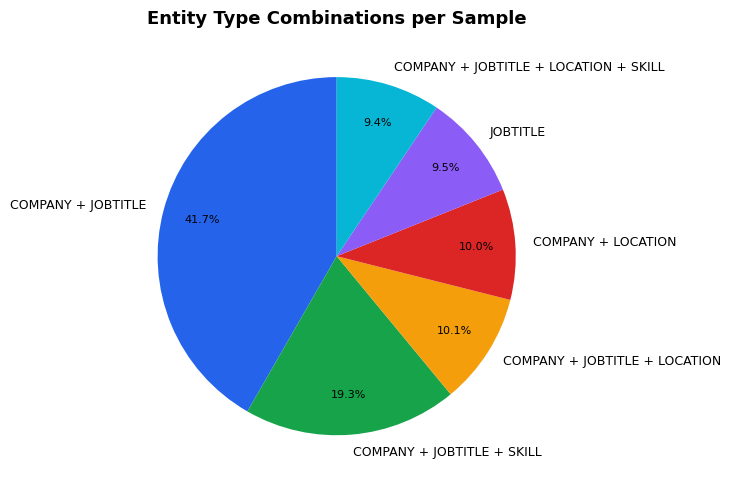


Samples with ALL 4 entity types: 296 (9.4%)
Samples needing cleaning: 2846 (90.6%)


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
combo_labels = [' + '.join(c) for c, _ in combo_counts.most_common()]
combo_vals   = [v for _, v in combo_counts.most_common()]

colors = ['#2563eb', '#16a34a', '#f59e0b', '#dc2626', '#8b5cf6', '#06b6d4']
wedges, texts, autotexts = ax.pie(
    combo_vals, labels=combo_labels, autopct='%1.1f%%',
    startangle=90, pctdistance=0.78, colors=colors,
    textprops={'fontsize': 9}
)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title('Entity Type Combinations per Sample', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nSamples with ALL 4 entity types: {combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")]} ({100*combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")]/len(train_data):.1f}%)')
print(f'Samples needing cleaning: {len(train_data) - combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")]} ({100*(len(train_data) - combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")])/len(train_data):.1f}%)')

### **Data Cleaning**

### **Handling the Punctuation Bug: Generating the Cleaned Dataset**


In [13]:
# Verify: are there any case variations in our entity tokens?
all_tokens_flat = [t for r in train_data for t in r['tokens']]
token_lower_map = {}
for t in set(all_tokens_flat):
    key = t.lower()
    token_lower_map.setdefault(key, set()).add(t)

case_variants = {k: v for k, v in token_lower_map.items() if len(v) > 1}
print(f"Tokens with case variations: {len(case_variants)}")
for k, v in case_variants.items():
    print(f'  "{k}" appears as: {v}')

Tokens with case variations: 2
  "data" appears as: {'data', 'Data'}
  "join" appears as: {'join', 'Join'}


We notice that "Data" appers in **upper** case when it is referred to the Data Scientist `JobTitle`, while it appears **lower** case when we talk about the data analyst `Skill`.



In [14]:
# Extract all unique entity values from the LABELED examples
entity_values = {}
for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']:
    entity_values[etype] = sorted(set(type_entities[etype]))
    print(f'\n{etype} ({len(entity_values[etype])} values):')
    for v in entity_values[etype]:
        print(f'  - "{v}"')


JOBTITLE (10 values):
  - "Business Analyst"
  - "Data Scientist"
  - "DevOps Engineer"
  - "Financial Analyst"
  - "HR Specialist"
  - "Marketing Manager"
  - "Product Manager"
  - "Sales Representative"
  - "Software Engineer"
  - "UX Designer"

COMPANY (10 values):
  - "CloudServices"
  - "DataSystems Inc"
  - "Digital Ventures"
  - "FutureSoft"
  - "Global Solutions"
  - "InnovateLabs"
  - "NextGen Industries"
  - "PrimeTech"
  - "SmartTech"
  - "TechCorp"

LOCATION (10 values):
  - "Atlanta"
  - "Austin"
  - "Boston"
  - "Chicago"
  - "Denver"
  - "Los Angeles"
  - "New York"
  - "Portland"
  - "San Francisco"
  - "Seattle"

SKILL (10 values):
  - "Agile"
  - "JavaScript"
  - "Python"
  - "SQL"
  - "cloud computing"
  - "communication"
  - "data analysis"
  - "leadership"
  - "machine learning"
  - "project management"


**For Customer-ready version we need to pip install spacy at the correct version**.

In [15]:
# Note: if spaCy fails after install, restart runtime and run cells again
# without re-executing this installation cell
!pip install -U spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: srsly
    Found existing installation: srsly 2.5.2
    Uninstalling srsly-2.5.2:
      Successfully uninstalled srsly-2.5.2
  Attempting uninstall: confection
    Found existing installation: confection 0.1.5
    Uninstalling confection-0.1.5:
      Successfully uninstalled confection-0.1.5
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.10
    Uninstalling thinc-8.3.10:
      Successfully uninstalled thinc-8.3.10
  Attempting uninstall: weasel
    Found existing installation: weasel 0.4.3
    Uninstalling weasel-0.4.3:
      Successfully uninstalled weasel-0.4.3
  Attempting uninstall: spacy
    Found existing installation: spacy 3

In [16]:
import spacy
nlp = spacy.load('en_core_web_sm')

# Step 1: Re-tokenize with spaCy
print("Step 1: Re-tokenizing with spaCy...")
print("=" * 55)

# Show example BEFORE re-tokenization
sample = train_data[1]
print(f"BEFORE (original tokenization):")
print(f"  Tokens: {sample['tokens']}")
print(f"  Labels: {sample['labels']}")

# Re-tokenize one sentence to show the difference
text = ' '.join(sample['tokens'])
doc = nlp(text)
print(f"\nAFTER (spaCy tokenization):")
print(f"  Tokens: {[t.text for t in doc]}")

Step 1: Re-tokenizing with spaCy...
BEFORE (original tokenization):
  Tokens: ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta.', 'Required', ':', 'leadership.']
  Labels: ['O', 'O', 'O', 'B-JOBTITLE', 'I-JOBTITLE', 'O', 'O', 'B-COMPANY', 'I-COMPANY', 'O', 'O', 'O', 'O', 'O']

AFTER (spaCy tokenization):
  Tokens: ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta', '.', 'Required', ':', 'leadership', '.']


In [17]:
import copy

def retokenize_with_spacy(data, has_labels=True):
    """
    Re-tokenize using spaCy to separate punctuation from words.
    Labels are re-aligned to the new tokens.
    """
    retokenized = []

    for sample in data:
        old_tokens = sample['tokens']
        old_labels = sample['labels'] if has_labels else None
        text = ' '.join(old_tokens)
        doc = nlp(text)

        new_tokens = []
        new_labels = []

        # Map each spaCy token back to the original token
        old_idx = 0
        old_char_pos = 0  # track position in original text

        for new_tok in doc:
            new_tokens.append(new_tok.text)

            if has_labels:
                # Find which original token this spaCy token came from
                # by matching character positions
                while old_idx < len(old_tokens) - 1 and old_char_pos + len(old_tokens[old_idx]) <= new_tok.idx:
                    old_char_pos += len(old_tokens[old_idx]) + 1  # +1 for space
                    old_idx += 1

                # If the new token is punctuation split from an entity-word,
                # it should be labeled O
                if new_tok.is_punct:
                    new_labels.append('O')
                else:
                    new_labels.append(old_labels[old_idx])

        entry = {'id': sample['id'], 'tokens': new_tokens}
        if has_labels:
            entry['labels'] = new_labels
        retokenized.append(entry)

    return retokenized

print("Re-tokenizing train set with spaCy...")
train_retokenized = retokenize_with_spacy(train_data, has_labels=True)
print(f"Done! {len(train_retokenized)} samples")

print("\nRe-tokenizing test set with spaCy...")
test_retokenized = retokenize_with_spacy(test_data, has_labels=False)
print(f"Done! {len(test_retokenized)} samples")

# Show example
sample_old = train_data[1]
sample_new = train_retokenized[1]
print(f"\nEXAMPLE:")
print(f"  BEFORE: {len(sample_old['tokens'])} tokens → {sample_old['tokens']}")
print(f"  AFTER:  {len(sample_new['tokens'])} tokens → {sample_new['tokens']}")
print(f"\n  Labels BEFORE: {sample_old['labels']}")
print(f"  Labels AFTER:  {sample_new['labels']}")

Re-tokenizing train set with spaCy...
Done! 3142 samples

Re-tokenizing test set with spaCy...
Done! 800 samples

EXAMPLE:
  BEFORE: 14 tokens → ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta.', 'Required', ':', 'leadership.']
  AFTER:  16 tokens → ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta', '.', 'Required', ':', 'leadership', '.']

  Labels BEFORE: ['O', 'O', 'O', 'B-JOBTITLE', 'I-JOBTITLE', 'O', 'O', 'B-COMPANY', 'I-COMPANY', 'O', 'O', 'O', 'O', 'O']
  Labels AFTER:  ['O', 'O', 'O', 'B-JOBTITLE', 'I-JOBTITLE', 'O', 'O', 'B-COMPANY', 'I-COMPANY', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [18]:
def reannotate_clean_v2(data):
    """
    Re-annotate entities on re-tokenized data.
    Handles abbreviations like 'Inc.' that spaCy keeps together.
    """
    patterns = []
    for etype, values in entity_values.items():
        for val in values:
            tokens = val.split()
            patterns.append((tokens, etype))
    patterns.sort(key=lambda x: -len(x[0]))

    cleaned = copy.deepcopy(data)
    corrections = 0

    for sample in cleaned:
        tokens = sample['tokens']
        labels = sample['labels']
        # Strip punctuation for matching only
        tokens_clean = [t.rstrip('.,;:!') for t in tokens]

        i = 0
        while i < len(tokens_clean):
            for pattern_tokens, etype in patterns:
                plen = len(pattern_tokens)
                if i + plen <= len(tokens_clean):
                    if tokens_clean[i:i+plen] == pattern_tokens:
                        if any(labels[i+j] == 'O' for j in range(plen)):
                            labels[i] = f'B-{etype}'
                            for j in range(1, plen):
                                labels[i+j] = f'I-{etype}'
                            corrections += plen
                        # Also clean the token itself
                        for j in range(plen):
                            tokens[i+j] = tokens_clean[i+j]
                        i += plen
                        break
            else:
                i += 1

    return cleaned, corrections

train_cleaned, num_corrections = reannotate_clean_v2(train_retokenized)
print(f"Total label corrections: {num_corrections}")

for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']:
    b_count = sum(1 for r in train_cleaned if any(l.startswith(f'B-{etype}') for l in r['labels']))
    print(f'  {etype}: {b_count}/3200 samples annotated')

Total label corrections: 7040
  JOBTITLE: 3142/3200 samples annotated
  COMPANY: 3142/3200 samples annotated
  LOCATION: 3142/3200 samples annotated
  SKILL: 3142/3200 samples annotated


In [19]:
# BIO consistency check on final cleaned data
print("BIO CONSISTENCY CHECK (final cleaned data):")
print("=" * 55)

for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']:
    b_count = sum(l == f'B-{etype}' for r in train_cleaned for l in r['labels'])
    i_count = sum(l == f'I-{etype}' for r in train_cleaned for l in r['labels'])
    print(f'\n  {etype}:')
    print(f'    B-{etype}: {b_count}')
    print(f'    I-{etype}: {i_count}')

# BIO sequence errors
bio_errors = 0
for r in train_cleaned:
    for i, lab in enumerate(r['labels']):
        if lab.startswith('I-'):
            etype = lab[2:]
            if i == 0 or (r['labels'][i-1] != f'B-{etype}' and r['labels'][i-1] != f'I-{etype}'):
                bio_errors += 1
print(f'\nBIO sequence errors: {bio_errors}')

# Unique entity values check
all_ents_clean = []
for r in train_cleaned:
    all_ents_clean.extend(extract_entities(r['tokens'], r['labels']))

type_ents_clean = {}
for etype, text in all_ents_clean:
    type_ents_clean.setdefault(etype, []).append(text)

print(f'\nUnique values per type:')
for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']:
    unique = sorted(set(type_ents_clean[etype]))
    print(f'  {etype}: {len(unique)} unique → {unique}')

BIO CONSISTENCY CHECK (final cleaned data):

  JOBTITLE:
    B-JOBTITLE: 3142
    I-JOBTITLE: 3142

  COMPANY:
    B-COMPANY: 3142
    I-COMPANY: 1190

  LOCATION:
    B-LOCATION: 3142
    I-LOCATION: 936

  SKILL:
    B-SKILL: 3142
    I-SKILL: 1236

BIO sequence errors: 0

Unique values per type:
  JOBTITLE: 10 unique → ['Business Analyst', 'Data Scientist', 'DevOps Engineer', 'Financial Analyst', 'HR Specialist', 'Marketing Manager', 'Product Manager', 'Sales Representative', 'Software Engineer', 'UX Designer']
  COMPANY: 10 unique → ['CloudServices', 'DataSystems Inc', 'Digital Ventures', 'FutureSoft', 'Global Solutions', 'InnovateLabs', 'NextGen Industries', 'PrimeTech', 'SmartTech', 'TechCorp']
  LOCATION: 10 unique → ['Atlanta', 'Austin', 'Boston', 'Chicago', 'Denver', 'Los Angeles', 'New York', 'Portland', 'San Francisco', 'Seattle']
  SKILL: 10 unique → ['Agile', 'JavaScript', 'Python', 'SQL', 'cloud computing', 'communication', 'data analysis', 'leadership', 'machine learning

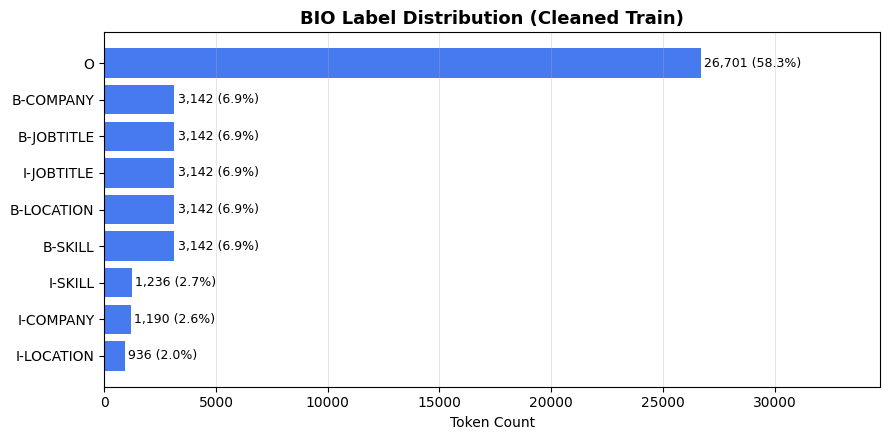

In [20]:
all_label_list_cleaned = [l for r in train_cleaned for l in r['labels']]
label_counts_cleaned = Counter(all_label_list_cleaned)
total_cleaned = len(all_label_list_cleaned)

labels_sorted_cleaned = sorted(label_counts_cleaned.items(), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(9, 4.5))
names = [l[0] for l in labels_sorted_cleaned][::-1]
vals  = [l[1] for l in labels_sorted_cleaned][::-1]
ax.barh(names, vals, color='#2563eb', alpha=0.85)
for i, v in enumerate(vals):
    ax.text(v + 150, i, f'{v:,} ({100*v/total_cleaned:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Token Count')
ax.set_title('BIO Label Distribution (Cleaned Train)', fontweight='bold', fontsize=13)
ax.set_xlim(0, max(vals)*1.3)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

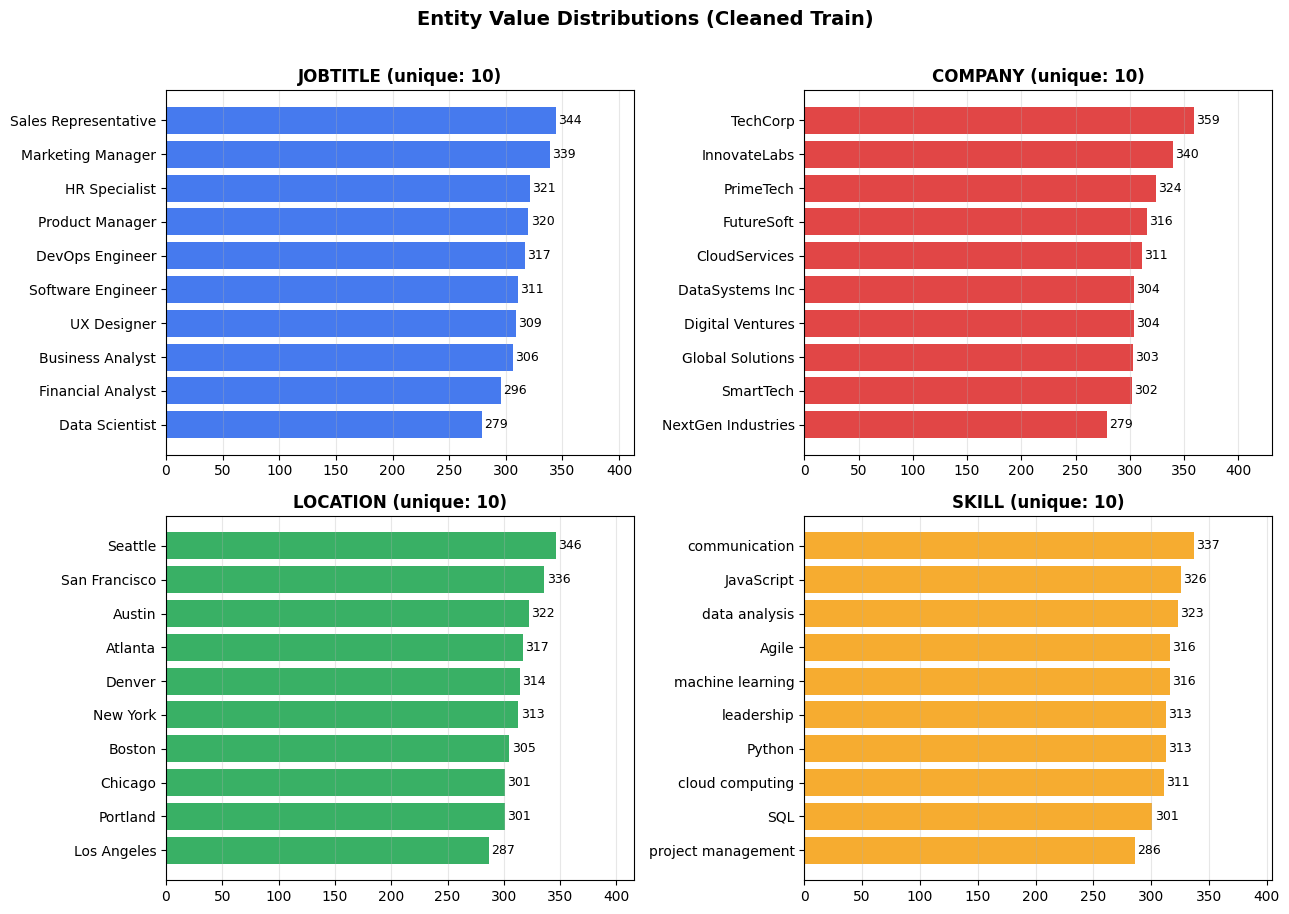

In [21]:
# Collect all entities from CLEANED data
all_entities_cleaned = []
for r in train_cleaned:
    all_entities_cleaned.extend(extract_entities(r['tokens'], r['labels']))

# Group by type
type_entities_cleaned = {}
for etype, text in all_entities_cleaned:
    type_entities_cleaned.setdefault(etype, []).append(text)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette = {'JOBTITLE': '#2563eb', 'COMPANY': '#dc2626',
           'LOCATION': '#16a34a', 'SKILL': '#f59e0b'}

for ax, etype in zip(axes.flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']):
    vals = Counter(type_entities_cleaned[etype]).most_common(10)
    names  = [v[0] for v in vals][::-1]
    counts = [v[1] for v in vals][::-1]
    ax.barh(names, counts, color=palette[etype], alpha=0.85)
    for i, v in enumerate(counts):
        ax.text(v + 2, i, str(v), va='center', fontsize=9)
    ax.set_title(f'{etype} (unique: {len(set(type_entities_cleaned[etype]))})',
                 fontweight='bold')
    ax.set_xlim(0, max(counts) * 1.2)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Entity Value Distributions (Cleaned Train)', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### **Save Cleaned Dataset**

In [22]:
import json

# Save cleaned train data
CLEAN_PATH = '/content/drive/MyDrive/DV-TM/DATA'
clean_train_file = os.path.join(CLEAN_PATH, 'train_cleaned.jsonl')

with open(clean_train_file, 'w') as f:
    for sample in train_cleaned:
        f.write(json.dumps(sample) + '\n')

print(f'Saved {len(train_cleaned)} cleaned train samples to {clean_train_file}')

# Save re-tokenized test data (same spaCy treatment, no labels)
clean_test_file = os.path.join(CLEAN_PATH, 'test_retokenized.jsonl')

with open(clean_test_file, 'w') as f:
    for sample in test_retokenized:
        f.write(json.dumps(sample) + '\n')

print(f'Saved {len(test_retokenized)} re-tokenized test samples to {clean_test_file}')

# Verify
print(f'\nFiles in {CLEAN_PATH}:')
for f in os.listdir(CLEAN_PATH):
    size = os.path.getsize(os.path.join(CLEAN_PATH, f)) / 1024
    print(f'  {f} ({size:.1f} KB)')

Saved 3142 cleaned train samples to /content/drive/MyDrive/DV-TM/DATA/train_cleaned.jsonl
Saved 800 re-tokenized test samples to /content/drive/MyDrive/DV-TM/DATA/test_retokenized.jsonl

Files in /content/drive/MyDrive/DV-TM/DATA:
  test.jsonl (121.6 KB)
  train.jsonl (821.1 KB)
  train_cleaned.jsonl (910.5 KB)
  test_retokenized.jsonl (127.6 KB)


In [23]:
# Check test retokenized
print("TEST original:")
print(f"  {test_data[0]['tokens']}")
print(f"  Keys: {list(test_data[0].keys())}")

print("\nTEST retokenized:")
print(f"  {test_retokenized[5]['tokens']}")
print(f"  Keys: {list(test_retokenized[5].keys())}")

TEST original:
  ['Product', 'Manager', 'position', 'available', 'at', 'Global', 'Solutions.', 'Requirements', ':', 'SQL.', 'Location', ':', 'Seattle.']
  Keys: ['id', 'tokens']

TEST retokenized:
  ['Data', 'Scientist', 'position', 'available', 'at', 'FutureSoft', '.', 'Requirements', ':', 'leadership', '.', 'Location', ':', 'Portland', '.']
  Keys: ['id', 'tokens']


In [ ]:
# Verify consistency between train_cleaned and test_retokenized
print("TRAIN CLEANED:")
print(f"  Sample: {train_cleaned[0]['id']}")
print(f"  Tokens: {train_cleaned[0]['tokens']}")
print(f"  Labels: {train_cleaned[0]['labels']}")
print(f"  Keys: {list(train_cleaned[0].keys())}")

print("\nTEST RETOKENIZED:")
print(f"  Sample: {test_retokenized[0]['id']}")
print(f"  Tokens: {test_retokenized[0]['tokens']}")
print(f"  Keys: {list(test_retokenized[0].keys())}")

# Check IDs are in order
print(f"\nTrain IDs aligned: {all(train_cleaned[i]['id'] == train_data[i]['id'] for i in range(len(train_data)))}")
print(f"Test IDs aligned:  {all(test_retokenized[i]['id'] == test_data[i]['id'] for i in range(len(test_data)))}")

TRAIN CLEANED:
  Sample: job_00000
  Tokens: ['NextGen', 'Industries', 'is', 'hiring', 'a', 'DevOps', 'Engineer', 'in', 'San', 'Francisco', 'with', 'SQL', 'experience', '.']
  Labels: ['B-COMPANY', 'I-COMPANY', 'O', 'O', 'O', 'B-JOBTITLE', 'I-JOBTITLE', 'O', 'B-LOCATION', 'I-LOCATION', 'O', 'B-SKILL', 'O', 'O']
  Keys: ['id', 'tokens', 'labels']

TEST RETOKENIZED:
  Sample: job_03200
  Tokens: ['Product', 'Manager', 'position', 'available', 'at', 'Global', 'Solutions', '.', 'Requirements', ':', 'SQL', '.', 'Location', ':', 'Seattle', '.']
  Keys: ['id', 'tokens']

Train IDs aligned: True
Test IDs aligned:  True


In [24]:
train_cleaned_lens = [len(r['tokens']) for r in train_cleaned]
test_retokenized_lens  = [len(r['tokens']) for r in test_retokenized]

print('TRAIN:')
print(f'  Min: {min(train_cleaned_lens)}, Max: {max(train_cleaned_lens)}, Mean: {np.mean(train_cleaned_lens):.1f}, Std: {np.std(train_cleaned_lens):.1f}')
print(f'\nTEST:')
print(f'  Min: {min(test_retokenized_lens)}, Max: {max(test_retokenized_lens)}, Mean: {np.mean(test_retokenized_lens):.1f}, Std: {np.std(test_retokenized_lens):.1f}')

TRAIN:
  Min: 10, Max: 18, Mean: 14.6, Std: 1.8

TEST:
  Min: 10, Max: 18, Mean: 14.6, Std: 1.8


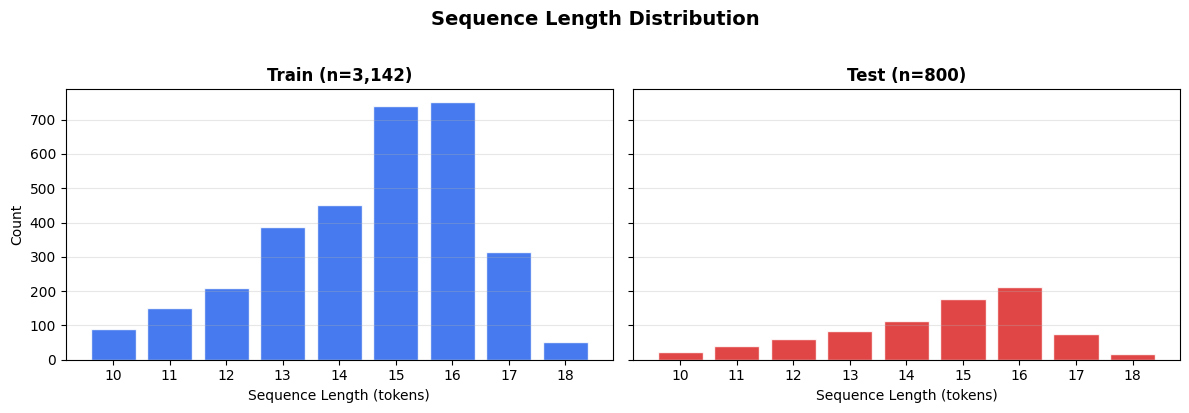

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, lens, title, color in [
    (axes[0], train_cleaned_lens, f'Train (n={len(train_cleaned):,})', '#2563eb'),
    (axes[1], test_retokenized_lens,  f'Test (n={len(test_retokenized):,})',  '#dc2626')
]:
    dist = Counter(lens)
    x = sorted(dist.keys())
    y = [dist[k] for k in x]
    ax.bar(x, y, color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Sequence Length (tokens)')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Count')
plt.suptitle('Sequence Length Distribution', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **POS Tagging Analysis**

In [26]:
# Processing the train_clean.jsonl file with spaCy
train_sentences_clean = [' '.join(r['tokens']) for r in train_cleaned]
docs = list(nlp.pipe(train_sentences_clean, batch_size=100))

# Extract POS tags from all tokens
pos_tags = []
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_tags.append(token.pos_)

pos_freq = Counter(pos_tags)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_freq.most_common():
    print(f"  {pos:{6}}: {count:5d} ({100*count/len(pos_tags):.1f}%)")

POS Tag Distribution:
  PROPN : 15227 (43.6%)
  NOUN  :  7552 (21.6%)
  ADP   :  3982 (11.4%)
  VERB  :  3917 (11.2%)
  AUX   :  1249 (3.6%)
  ADJ   :  1124 (3.2%)
  DET   :   912 (2.6%)
  ADV   :   354 (1.0%)
  PRON  :   307 (0.9%)
  PART  :   307 (0.9%)
  SCONJ :    27 (0.1%)


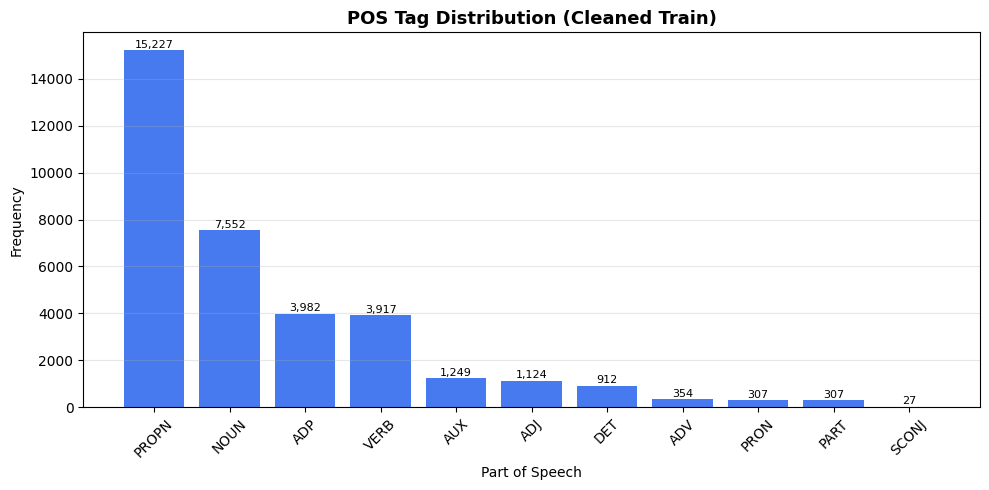

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

pos_sorted = pos_freq.most_common()
names = [p[0] for p in pos_sorted]
counts = [p[1] for p in pos_sorted]

ax.bar(names, counts, color='#2563eb', alpha=0.85)
for i, v in enumerate(counts):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=8)
ax.set_xlabel('Part of Speech')
ax.set_ylabel('Frequency')
ax.set_title('POS Tag Distribution (Cleaned Train)', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# POS tags grouped by entity type
entity_pos = {'JOBTITLE': [], 'COMPANY': [], 'LOCATION': [], 'SKILL': [], 'O': []}

for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if token.is_punct or token.is_space:
            continue
        etype = 'O' if label == 'O' else label.split('-')[1]
        entity_pos[etype].append(token.pos_)

print("POS Distribution by Entity Type:")
print("=" * 60)
for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']:
    pos_dist = Counter(entity_pos[etype])
    total = len(entity_pos[etype])
    print(f'\n  {etype}:')
    for pos, count in pos_dist.most_common(5):
        print(f'    {pos:{6}}: {count:5d} ({100*count/total:.1f}%)')

POS Distribution by Entity Type:

  JOBTITLE:
    PROPN :  5274 (83.9%)
    NOUN  :   841 (13.4%)
    ADJ   :   169 (2.7%)

  COMPANY:
    PROPN :  4304 (99.4%)
    NOUN  :    19 (0.4%)
    ADV   :     9 (0.2%)

  LOCATION:
    PROPN :  4078 (100.0%)

  SKILL:
    NOUN  :  2946 (67.3%)
    PROPN :  1367 (31.2%)
    VERB  :    65 (1.5%)

  O:
    ADP   :  3982 (25.1%)
    VERB  :  3852 (24.2%)
    NOUN  :  3746 (23.6%)
    AUX   :  1249 (7.9%)
    ADJ   :   955 (6.0%)


In [29]:
# Find JOBTITLE tokens tagged as ADJ by spaCy
print("JOBTITLE tokens with POS = ADJ:")
print("=" * 50)

adj_jobtitles = Counter()
for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if label in ['B-JOBTITLE', 'I-JOBTITLE'] and token.pos_ == 'ADJ':
            adj_jobtitles[token.text] += 1

for word, count in adj_jobtitles.most_common():
    print(f'  "{word}": {count} times')

JOBTITLE tokens with POS = ADJ:
  "Specialist": 139 times
  "Financial": 30 times


In [30]:
# Find COMPANY tokens tagged as ADV or NOUN by spaCy
print("\nCOMPANY tokens with POS = ADV:")
adv_company = Counter()
noun_company = Counter()
for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if label in ['B-COMPANY', 'I-COMPANY']:
            if token.pos_ == 'ADV':
                adv_company[token.text] += 1
            elif token.pos_ == 'NOUN':
                noun_company[token.text] += 1

for word, count in adv_company.most_common():
    print(f'  "{word}": {count} times')

print("\nCOMPANY tokens with POS = NOUN:")
for word, count in noun_company.most_common():
    print(f'  "{word}": {count} times')


COMPANY tokens with POS = ADV:
  "FutureSoft": 9 times

COMPANY tokens with POS = NOUN:
  "CloudServices": 19 times


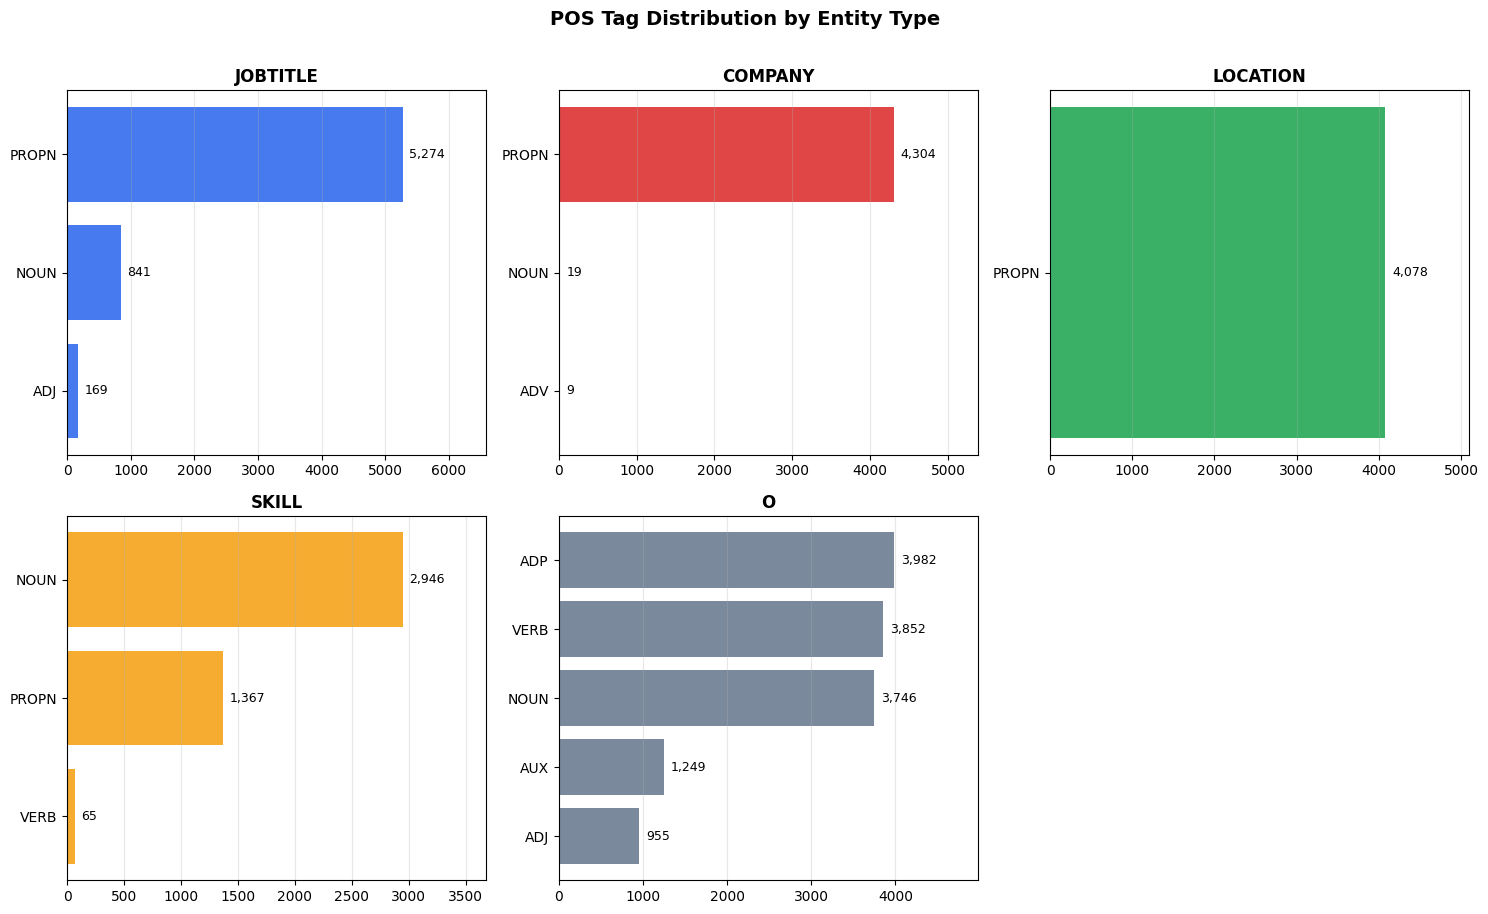

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flat

palette_etype = {'JOBTITLE': '#2563eb', 'COMPANY': '#dc2626',
                 'LOCATION': '#16a34a', 'SKILL': '#f59e0b', 'O': '#64748b'}

for ax, etype in zip(axes_flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']):
    pos_dist = Counter(entity_pos[etype])
    top = pos_dist.most_common(5)
    names = [p[0] for p in top][::-1]
    counts = [p[1] for p in top][::-1]
    bars = ax.barh(names, counts, color=palette_etype[etype], alpha=0.85)
    for i, v in enumerate(counts):
        ax.text(v + max(counts)*0.02, i, f'{v:,}', va='center', fontsize=9)
    ax.set_title(etype, fontweight='bold', fontsize=12)
    ax.set_xlim(0, max(counts) * 1.25)
    ax.grid(axis='x', alpha=0.3)

# Hide the 6th empty subplot
axes_flat[5].set_visible(False)

plt.suptitle('POS Tag Distribution by Entity Type', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Questo grafico racconta una storia chiara. Ogni tipo di entità ha un profilo POS distintivo:

* LOCATION è il caso più pulito — 100% PROPN. SpaCy riconosce perfettamente le città come nomi propri. Questo significa che il POS tag da solo potrebbe quasi identificare le location.
* COMPANY è quasi tutto PROPN (99.4%), con poche eccezioni dove spaCy non riconosce nomi inventati come "CloudServices" (NOUN) e "FutureSoft" (ADV). Queste sono limitazioni di spaCy su vocabolario di dominio.
* JOBTITLE è prevalentemente PROPN (84%) ma con una componente significativa di NOUN (13.4%) e ADJ (2.7%). Questo riflette la natura composita dei job titles — "Financial" è grammaticalmente un aggettivo, "Specialist" può essere interpretato come nome comune.
* SKILL è l'unico tipo dove NOUN domina su PROPN (67% vs 31%). Questo distingue nettamente le skill dalle altre entità. Le skill tecniche (Python, JavaScript, SQL) sono PROPN, mentre le soft skill (communication, leadership) e le skill composte (machine learning, data analysis) sono NOUN.
* O mostra un profilo completamente diverso — dominato da ADP (preposizioni come "at", "in", "with"), VERB ("hiring", "needs") e NOUN ("position", "experience"). Nessun overlap significativo con il profilo delle entità.

Il takeaway principale: il POS tag è un segnale discriminante che potrebbe essere usato come feature aggiuntiva per migliorare le predizioni del nostro primo modello basato sui Neural Network.

### **Lemma Analysis**

In [32]:
# Extract lemmas
all_tokens_text = []
all_lemmas = []

for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            all_tokens_text.append(token.text.lower())
            all_lemmas.append(token.lemma_.lower())

print(f"Unique tokens: {len(set(all_tokens_text))}")
print(f"Unique lemmas: {len(set(all_lemmas))}")
print(f"Vocabulary reduction: {(1 - len(set(all_lemmas))/len(set(all_tokens_text)))*100:.1f}%")

# Show examples of lemmatization
print(f"\n{'Token':{20}} {'Lemma':{20}} {'Changed?'}")
print("-" * 50)
seen = set()
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            if token.text != token.lemma_ and token.text not in seen:
                print(f"{token.text:{20}} {token.lemma_:{20}} YES")
                seen.add(token.text)

Unique tokens: 92
Unique lemmas: 94
Vocabulary reduction: -2.2%

Token                Lemma                Changed?
--------------------------------------------------
is                   be                   YES
hiring               hire                 YES
Apply                apply                YES
Required             require              YES
Excellent            excellent            YES
Analyst              analyst              YES
Skills               skill                YES
needs                need                 YES
We                   we                   YES
're                  be                   YES
looking              look                 YES
HR                   hr                   YES
Specialist           specialist           YES
Seeking              seek                 YES
located              locate               YES
Must                 must                 YES
data                 datum                YES
skills               skill                YES
Join 

In [33]:
# Deep analysis: lemmatization impact on entities
print("LEMMATIZATION IMPACT ON ENTITIES:")
print("=" * 60)

entity_lemma_changes = {'JOBTITLE': [], 'COMPANY': [], 'LOCATION': [], 'SKILL': [], 'O': []}

for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if token.is_punct or token.is_space:
            continue
        etype = 'O' if label == 'O' else label.split('-')[1]
        if token.text.lower() != token.lemma_.lower():
            entity_lemma_changes[etype].append((token.text, token.lemma_))

for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']:
    changes = Counter(entity_lemma_changes[etype])
    total_tokens = len(entity_pos[etype])  # reuse from POS analysis
    changed = len(entity_lemma_changes[etype])
    print(f'\n  {etype}: {changed}/{total_tokens} tokens changed ({100*changed/total_tokens:.1f}%)')
    if changes:
        for (orig, lemma), count in changes.most_common(5):
            print(f'    "{orig}" → "{lemma}" ({count} times)')

LEMMATIZATION IMPACT ON ENTITIES:

  JOBTITLE: 197/6284 tokens changed (3.1%)
    "Sales" → "sale" (134 times)
    "Data" → "datum" (63 times)

  COMPANY: 19/4332 tokens changed (0.4%)
    "CloudServices" → "cloudservice" (19 times)

  LOCATION: 0/4078 tokens changed (0.0%)

  SKILL: 336/4378 tokens changed (7.7%)
    "data" → "datum" (304 times)
    "learning" → "learn" (32 times)

  O: 3994/15886 tokens changed (25.1%)
    "Required" → "require" (654 times)
    "Skills" → "skill" (336 times)
    "needs" → "need" (317 times)
    "seeks" → "seek" (314 times)
    "'re" → "be" (307 times)


**Key Findings**

The lemmatization analysis reveals that this preprocessing step would be **harmful** for our NER task:

**Entities are barely affected (0-7.7%):**
- **LOCATION: 0% changed** — city names are already in base form (Boston, Seattle, etc.)
- **COMPANY: 0.4% changed** — only "CloudServices" → "cloudservice", which loses the proper noun capitalization
- **JOBTITLE: 3.1% changed** — "Sales" → "sale" and "Data" → "datum" would **break entity recognition** (the model would never see "Data Scientist" but "datum Scientist" instead)
- **SKILL: 7.7% changed** — "data analysis" would become "datum analysis" and "machine learning" would become "machine learn", destroying recognizable skill names

**Context words are heavily affected (25.1%):**
- Verbs like "hiring" → "hire", "needs" → "need", "seeks" → "seek" all collapse into base forms
- This would remove useful contextual signals — for example, "needs" (present tense, 3rd person) tells the model that a company name likely precedes it

**Conclusion:** Lemmatization is not applied in our preprocessing pipeline because:
1. It corrupts entity names ("Data" → "datum", "Sales" → "sale")
2. It reduces contextual variety in the O tokens, which are the signals the model uses to identify entities
3. The vocabulary is already small enough (92 unique tokens) that sparsity is not a problem

### **Dependency Parsing**

In [34]:
dep_tags = []
entity_dep = {'JOBTITLE': [], 'COMPANY': [], 'LOCATION': [], 'SKILL': [], 'O': []}

for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if token.is_punct or token.is_space:
            continue
        dep_tags.append(token.dep_)
        etype = 'O' if label == 'O' else label.split('-')[1]
        entity_dep[etype].append(token.dep_)

# Overall dependency distribution
dep_freq = Counter(dep_tags)
print("Dependency Tag Distribution:")
print("=" * 45)
for dep, count in dep_freq.most_common(10):
    print(f"  {dep:{12}}: {count:5d} ({100*count/len(dep_tags):.1f}%) — {spacy.explain(dep)}")

# Dependency by entity type
print("\n\nDependency Distribution by Entity Type:")
print("=" * 55)
for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']:
    dep_dist = Counter(entity_dep[etype])
    total = len(entity_dep[etype])
    print(f'\n  {etype}:')
    for dep, count in dep_dist.most_common(5):
        print(f'    {dep:{12}}: {count:5d} ({100*count/total:.1f}%) — {spacy.explain(dep)}')

Dependency Tag Distribution:
  compound    :  8298 (23.7%) — compound
  ROOT        :  5997 (17.2%) — root
  prep        :  3982 (11.4%) — prepositional modifier
  pobj        :  3922 (11.2%) — object of preposition
  appos       :  2962 (8.5%) — appositional modifier
  dobj        :  2712 (7.8%) — direct object
  nsubj       :  1660 (4.7%) — nominal subject
  aux         :  1556 (4.5%) — auxiliary
  amod        :  1075 (3.1%) — adjectival modifier
  det         :   912 (2.6%) — determiner


Dependency Distribution by Entity Type:

  JOBTITLE:
    compound    :  4290 (68.3%) — compound
    dobj        :   874 (13.9%) — direct object
    pobj        :   532 (8.5%) — object of preposition
    acl         :   304 (4.8%) — clausal modifier of noun (adjectival clause)
    nsubj       :   119 (1.9%) — nominal subject

  COMPANY:
    pobj        :  1225 (28.3%) — object of preposition
    compound    :  1219 (28.1%) — compound
    nsubj       :   906 (20.9%) — nominal subject
    dobj        

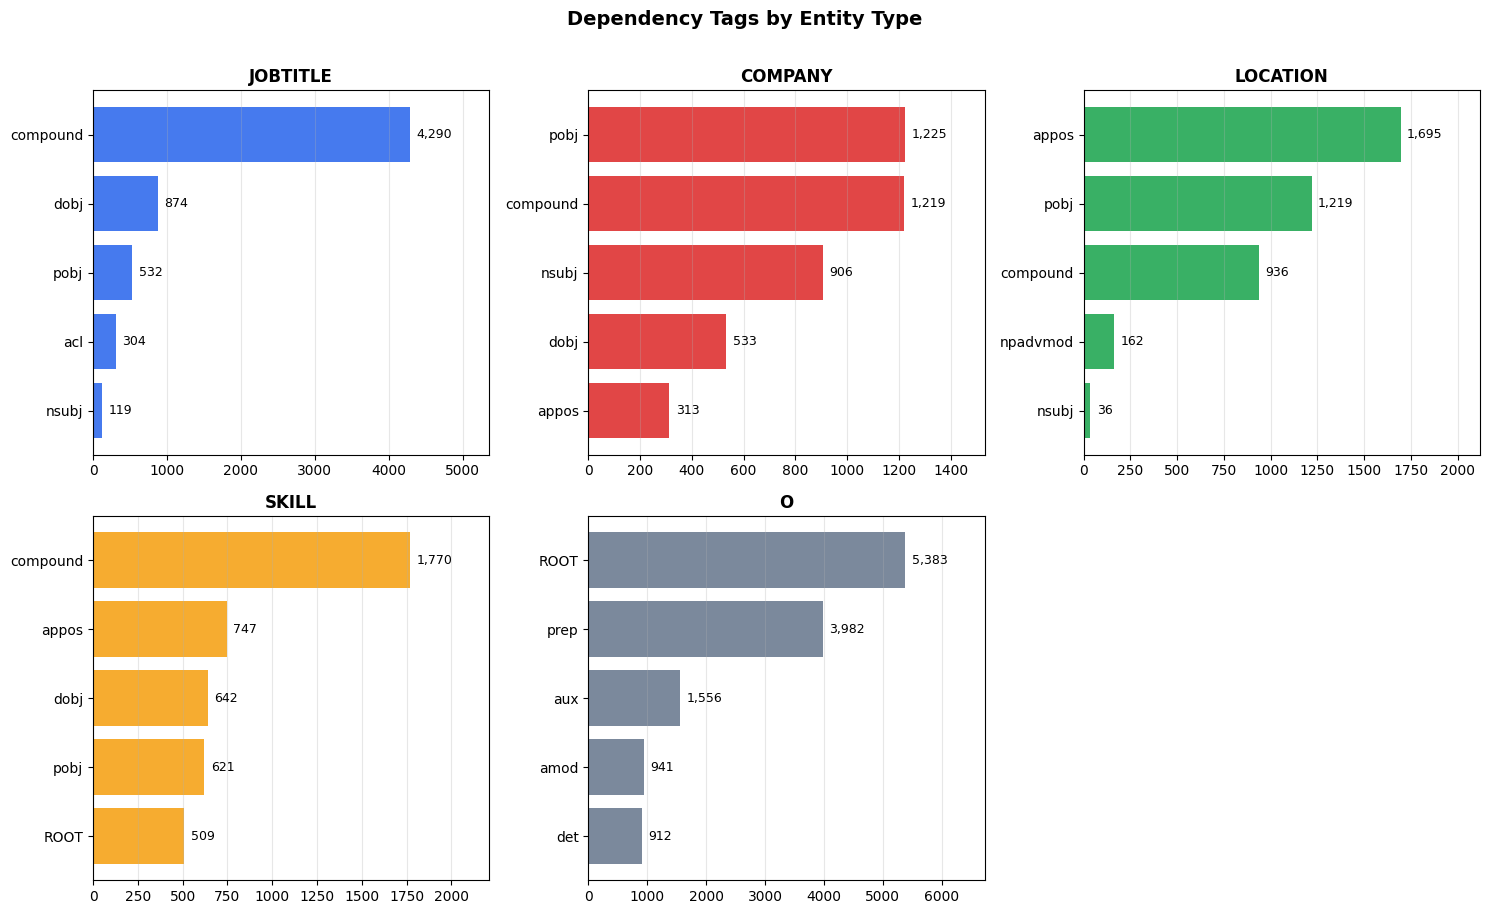

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flat

palette_etype = {'JOBTITLE': '#2563eb', 'COMPANY': '#dc2626',
                 'LOCATION': '#16a34a', 'SKILL': '#f59e0b', 'O': '#64748b'}

for ax, etype in zip(axes_flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']):
    dep_dist = Counter(entity_dep[etype])
    top = dep_dist.most_common(5)
    names = [p[0] for p in top][::-1]
    counts = [p[1] for p in top][::-1]
    ax.barh(names, counts, color=palette_etype[etype], alpha=0.85)
    for i, v in enumerate(counts):
        ax.text(v + max(counts)*0.02, i, f'{v:,}', va='center', fontsize=9)
    ax.set_title(etype, fontweight='bold', fontsize=12)
    ax.set_xlim(0, max(counts) * 1.25)
    ax.grid(axis='x', alpha=0.3)

axes_flat[5].set_visible(False)

plt.suptitle('Dependency Tags by Entity Type', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [36]:
from spacy import displacy

# Show 2 sample sentences with dependency visualization
for idx in range(5):
    print(f"\n{train_cleaned[idx]['id']}: {docs[idx].text}\n")
    displacy.render(docs[idx], style='dep', jupyter=True,
                    options={'distance': 90, 'compact': True})


job_00000: NextGen Industries is hiring a DevOps Engineer in San Francisco with SQL experience .




job_00001: Apply now : Software Engineer position , DataSystems Inc , Atlanta . Required : leadership .




job_00002: Excellent opportunity : Business Analyst at NextGen Industries , Seattle . Skills : Python .




job_00003: NextGen Industries in Austin needs Product Manager proficient in Agile .




job_00004: We 're looking for a Data Scientist with project management to join Digital Ventures in Chicago .



In [37]:
from spacy.tokens import Span
random.seed(16)

# Custom colors for our entity types
colors = {
    'JOBTITLE': '#2563eb',
    'COMPANY': '#dc2626',
    'LOCATION': '#16a34a',
    'SKILL': '#f59e0b'
}

# Pick 5 random samples and visualize
sample_indices = random.sample(range(len(docs)), 10)

for idx in sample_indices:
    doc = docs[idx]
    sample = train_cleaned[idx]

    # Build entity spans from our BIO labels
    ents = []
    i = 0
    while i < len(sample['labels']):
        label = sample['labels'][i]
        if label.startswith('B-'):
            etype = label[2:]
            start = i
            end = i + 1
            while end < len(sample['labels']) and sample['labels'][end] == f'I-{etype}':
                end += 1
            ents.append(Span(doc, start, end, label=etype))
            i = end
        else:
            i += 1

    doc.ents = ents
    displacy.render(doc, style='ent', jupyter=True,
                    options={'colors': colors})
    print()

### **Topic Modeling (NMF) — Applicability Assessment**

Topic modeling techniques like LDA (Latent Dirichlet Allocation) and NMF (Non-Negative Matrix Factorization) are commonly used in text mining to discover hidden thematic structures in document collections. We investigated whether these techniques could provide useful insights for our job posting NER dataset.

**Why Topic Modeling Is Not Applicable to Our Dataset**

After applying NMF with TF-IDF vectorization, we found that **topic modeling does not yield meaningful results** for this dataset. The evidence is twofold:

**1. No optimal number of topics exists.** The reconstruction error decreases linearly as we increase the number of topics (see plot below), with no "elbow point" indicating a natural clustering. This means the data does not contain distinct thematic groups — unlike a news corpus where articles naturally cluster into politics, sports, science, etc.

**2. Discovered topics heavily overlap.** The top words in each topic are largely shared across all topics (e.g., "engineer", "data", "position" appear in multiple topics). This is because all 3,200 sentences describe the same thing, a job posting, using a shared vocabulary of only 78 features after TF-IDF filtering.

**Root Cause**

The dataset was generated from **sentence templates** with a **closed vocabulary** of 136 unique tokens. The variation across sentences is not thematic (different subjects) but **structural** (different syntactic patterns) and **entity-based** (different combinations of company names, job titles, locations, and skills). Topic modeling is designed to capture thematic variation, not structural or entity-level variation.

**Conclusion**

This finding reinforces that our task is fundamentally a **Named Entity Recognition** problem, not a topic classification problem. All sentences share the same theme (job postings) and the same vocabulary, so the only meaningful variation is **which tokens are entities and which are not**.

### <font color='red'>**Importante giustificare come mai non usiamo queste tecniche nel nostro progetto, come mai non sono utili... e poi eviterei di mettere questi codici relativi il Topic Modelling**

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Reconstruct sentences from cleaned data
train_sentences_clean = [' '.join(r['tokens']) for r in train_cleaned]

# TF-IDF vectorization
# Lower thresholds because our vocab is small
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = tfidf.fit_transform(train_sentences_clean)

print(f"Document-Term Matrix shape: {dtm.shape}")
print(f"Features (words): {len(tfidf.get_feature_names_out())}")
print(f"Feature names: {tfidf.get_feature_names_out()}")

Document-Term Matrix shape: (3142, 78)
Features (words): 78
Feature names: ['agile' 'analysis' 'analyst' 'angeles' 'apply' 'atlanta' 'austin'
 'available' 'boston' 'business' 'chicago' 'cloud' 'cloudservices'
 'communication' 'computing' 'data' 'datasystems' 'denver' 'designer'
 'devops' 'digital' 'engineer' 'excellent' 'experience' 'financial'
 'francisco' 'futuresoft' 'global' 'hiring' 'hr' 'industries'
 'innovatelabs' 'javascript' 'join' 'key' 'know' 'leadership' 'learning'
 'located' 'location' 'looking' 'los' 'machine' 'management' 'manager'
 'marketing' 'needs' 'new' 'nextgen' 'opportunity' 'portland' 'position'
 'primetech' 'product' 'proficient' 'project' 'python' 'representative'
 'required' 'requirements' 'role' 'sales' 'san' 'scientist' 'seattle'
 'seeking' 'seeks' 'skill' 'skills' 'smarttech' 'software' 'solutions'
 'specialist' 'sql' 'techcorp' 'ux' 'ventures' 'york']


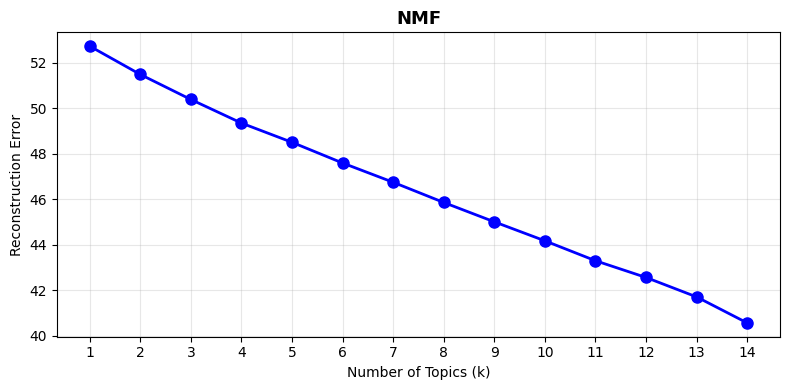

In [39]:
train_sentences_clean = [' '.join(r['tokens']) for r in train_cleaned]
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = tfidf.fit_transform(train_sentences_clean)

errors = []
K_range = range(1, 15)
for k in K_range:
    nmf = NMF(n_components=k, random_state=42, max_iter=500)
    nmf.fit(dtm)
    errors.append(nmf.reconstruction_err_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), errors, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Reconstruction Error')
ax.set_title('NMF', fontweight='bold', fontsize=13)
ax.set_xticks(list(K_range))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
nmf_model = NMF(n_components=6, random_state=42, max_iter=500)
nmf_model.fit(dtm)

for index, topic in enumerate(nmf_model.components_):
    top_words = [tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    print(f'Topic #{index}: {top_words}')

Topic #0: ['analyst', 'software', 'devops', 'data', 'engineer', 'seeking', 'located', 'excellent', 'opportunity', 'skills']
Topic #1: ['software', 'data', 'devops', 'engineer', 'required', 'apply', 'location', 'available', 'requirements', 'position']
Topic #2: ['austin', 'cloud', 'computing', 'data', 'software', 'devops', 'engineer', 'key', 'role', 'skill']
Topic #3: ['hr', 'specialist', 'ux', 'designer', 'representative', 'sales', 'know', 'seeks', 'proficient', 'needs']
Topic #4: ['communication', 'york', 'new', 'san', 'francisco', 'product', 'marketing', 'experience', 'hiring', 'manager']
Topic #5: ['javascript', 'sql', 'data', 'financial', 'business', 'location', 'required', 'analyst', 'looking', 'join']
